In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from sklearn.impute import KNNImputer
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/magicbricks_rentals.csv")
df.shape

(5870, 17)

In [181]:
df.head()

,property_type,property_subtype,city,locality,title,price_raw,price_per_sqft_raw,carpet_area_raw,floor_raw,status_raw,furnishing,facing,overlooking,amenity_count,nearby_raw,description_raw,scraped_at
0,flat,flat,mumbai,andheri-east,"1 BHK Flat for Rent in Andheri East, Mumbai","₹42,000",NaN,NaN,4 out of 4,Immediately,Semi-Furnished,East,Garden/Park,NaN,"Andheri metro station, Mumbai - 5 Minutes | Ag...",NaN,2026-07-05T12:18:43
1,flat,flat,mumbai,andheri-east,"2 BHK Flat for Rent in Andheri East, Mumbai","₹83,000",NaN,911 sqft,4 out of 10,Immediately,Furnished,East,"Main Road, Garden/Park, Pool",NaN,"Andheri metro station, Mumbai - 5 Minutes | An...",NaN,2026-07-05T12:18:44
2,flat,flat,mumbai,andheri-east,"1 BHK Flat for Rent in Andheri East, Mumbai","₹25,000",NaN,300 sqft,4 out of 7,From Aug '26,Semi-Furnished,NaN,NaN,NaN,Andheri (E) Bisleri Factory Bus Stop | Pinnacl...,NaN,2026-07-05T12:18:44
3,flat,flat,mumbai,andheri-east,"2 BHK Flat for Rent in Andheri East, Mumbai","₹54,000",NaN,660 sqft,5 out of 10,Immediately,Unfurnished,North - East,Garden/Park,NaN,"Andheri metro station, Mumbai | Chakala (Jb Na...",NaN,2026-07-05T12:18:45
4,flat,flat,mumbai,andheri-east,"3 BHK Flat for Rent in Andheri East, Mumbai",₹1.3 Lac,NaN,1270 sqft,7 out of 12,Immediately,Semi-Furnished,East,"Garden/Park, Main Road",NaN,"Andheri metro station, Mumbai - 5 Minutes | An...",NaN,2026-07-05T12:18:48


##checking Null values in all Features

In [182]:
df.isna().sum()

property_type            0
property_subtype       232
city                     0
locality                 0
title                    0
price_raw                0
price_per_sqft_raw    5803
carpet_area_raw        638
floor_raw              483
status_raw               0
furnishing              14
facing                 778
overlooking            934
amenity_count         5832
nearby_raw            2807
description_raw       5870
scraped_at               0
dtype: int64

### Checking if property_type and property_subtype are same 

In [183]:
df[(df["property_type"] != df["property_subtype"]) & ~(df["property_subtype"].isna())]

,property_type,property_subtype,city,locality,title,price_raw,price_per_sqft_raw,carpet_area_raw,floor_raw,status_raw,furnishing,facing,overlooking,amenity_count,nearby_raw,description_raw,scraped_at
855,flat,villa,mumbai,bandra-west,1 BHK Flat for Rent in Pali Village Mumbai,₹1.1 Lac,NaN,550 sqft,Ground out of 1,Immediately,Semi-Furnished,South -West,"Garden/Park, Main Road",NaN,NaN,NaN,2026-07-05T13:33:50
857,flat,villa,mumbai,bandra-west,3 BHK Flat for Rent in Pali Village Mumbai,₹1.6 Lac,NaN,1000 sqft,6 out of 7,Immediately,Furnished,East,Main Road,NaN,NaN,NaN,2026-07-05T13:33:51
890,flat,villa,mumbai,bandra-west,1 BHK Flat for Rent in Pali Village Mumbai,₹\n1.1 Lac,NaN,550 sqft,Ground out of 1,Immediately,Semi-Furnished,South -West,"Garden/Park, Main Road",NaN,NaN,NaN,2026-07-05T13:34:11
892,flat,villa,mumbai,bandra-west,3 BHK Flat for Rent in Pali Village Mumbai,₹\n1.6 Lac,NaN,1000 sqft,6 out of 7,Immediately,Furnished,East,Main Road,NaN,NaN,NaN,2026-07-05T13:34:12
1616,flat,apartment,mumbai,mira-road,"Apartment for Rent in Mira Road, Mumbai",Call for Price,NaN,NaN,NaN,Immediately,NaN,NaN,NaN,NaN,Senthome Public School | Holy Cross Convent Sc...,NaN,2026-07-05T14:09:43
1644,flat,apartment,mumbai,mira-road,"Apartment for Rent in Mira Road, Mumbai",Call for Price,NaN,NaN,NaN,Immediately,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-05T14:10:03
2484,house,flat,mumbai,goregaon-east,5 BHK Flat for Rent in Goregaon East Mumbai,₹5 Lac,NaN,2500 sqft,23 out of 51,Immediately,Furnished,East,"Garden/Park, Main Road",NaN,Aarey Metro Station - 5 Minutes | Vakratunda C...,NaN,2026-07-05T14:50:25
2486,house,flat,mumbai,goregaon-east,5 BHK Flat for Rent in Goregaon East Mumbai,₹\n5 Lac,NaN,2500 sqft,23 out of 51,Immediately,Furnished,East,"Garden/Park, Main Road",NaN,NaN,NaN,2026-07-05T14:50:47
2911,flat,penthouse,mumbai,worli,4 BHK Penthouse for Rent in Worli Mumbai,₹6 Lac,NaN,2357 sqft,45 out of 68,Immediately,Semi-Furnished,South,"Garden/Park, Pool, Main Road",NaN,Worli Metro Station - 5 Minutes | Currey Road ...,NaN,2026-07-05T15:12:00
2962,flat,penthouse,mumbai,worli,4 BHK Penthouse for Rent in Worli Mumbai,₹\n6 Lac,NaN,2357 sqft,45 out of 68,Immediately,Semi-Furnished,South,"Garden/Park, Pool, Main Road",NaN,NaN,NaN,2026-07-05T15:12:28


### Columns Dropped

- **`city`**: Dropped because all records belong to **Mumbai**, making the feature constant and non-informative for prediction.

- **`property_subtype`**: Dropped because it is almost identical to **`property_type`**. Only 24 records differ, while the remaining values are either the same or missing, making it redundant.

- **`amenity_count`**: Dropped due to a very high proportion of missing values, indicating that the information was not scraped reliably.

- **`description_raw`**: Dropped because the field is almost entirely missing, making it unsuitable for analysis or feature engineering.

- **`price_per_sq_ft`**: Dropped to prevent **data leakage**. Since it is directly derived from the target variable (**rent**), including it would provide the model with information that would not be available at prediction time.

In [184]:
drop_col = ["city","property_subtype","amenity_count","description_raw","price_per_sqft_raw","scraped_at"]

df.drop(columns=drop_col,axis = 1,errors = 'ignore', inplace=True)

In [185]:
df.head()

,property_type,locality,title,price_raw,carpet_area_raw,floor_raw,status_raw,furnishing,facing,overlooking,nearby_raw
0,flat,andheri-east,"1 BHK Flat for Rent in Andheri East, Mumbai","₹42,000",NaN,4 out of 4,Immediately,Semi-Furnished,East,Garden/Park,"Andheri metro station, Mumbai - 5 Minutes | Ag..."
1,flat,andheri-east,"2 BHK Flat for Rent in Andheri East, Mumbai","₹83,000",911 sqft,4 out of 10,Immediately,Furnished,East,"Main Road, Garden/Park, Pool","Andheri metro station, Mumbai - 5 Minutes | An..."
2,flat,andheri-east,"1 BHK Flat for Rent in Andheri East, Mumbai","₹25,000",300 sqft,4 out of 7,From Aug '26,Semi-Furnished,NaN,NaN,Andheri (E) Bisleri Factory Bus Stop | Pinnacl...
3,flat,andheri-east,"2 BHK Flat for Rent in Andheri East, Mumbai","₹54,000",660 sqft,5 out of 10,Immediately,Unfurnished,North - East,Garden/Park,"Andheri metro station, Mumbai | Chakala (Jb Na..."
4,flat,andheri-east,"3 BHK Flat for Rent in Andheri East, Mumbai",₹1.3 Lac,1270 sqft,7 out of 12,Immediately,Semi-Furnished,East,"Garden/Park, Main Road","Andheri metro station, Mumbai - 5 Minutes | An..."


### Exploring **rent** Column

In [186]:
df["price_raw"].unique()


array(['₹42,000', '₹83,000', '₹25,000', '₹54,000', '₹1.3 Lac', '₹35,000',
       '₹65,000', '₹2.1 Lac', '₹80,000', '₹57,000', '₹48,000', '₹4.5 Lac',
       '₹55,000', '₹3.8 Lac', '₹60,000', '₹90,000', '₹3.4 Lac', '₹78,000',
       '₹1 Lac', '₹1.7 Lac', '₹68,000', '₹1.8 Lac', '₹75,000', '₹1.2 Lac',
       '₹3 Lac', '₹\n42,000', '₹\n83,000', '₹\n25,000', '₹\n54,000',
       '₹\n1.3 Lac', '₹\n35,000', '₹\n65,000', '₹\n2.1 Lac', '₹\n80,000',
       '₹\n57,000', '₹\n48,000', '₹\n4.5 Lac', '₹\n55,000', '₹\n3.8 Lac',
       '₹\n60,000', '₹\n90,000', '₹\n3.4 Lac', '₹\n78,000', '₹\n1 Lac',
       '₹\n1.7 Lac', '₹\n68,000', '₹\n1.8 Lac', '₹\n75,000', '₹\n1.2 Lac',
       '₹\n3 Lac', '₹50,000', '₹53,000', '₹38,000', '₹33,000', '₹52,000',
       '₹37,000', '₹46,000', '₹45,000', '₹36,000', '₹44,900', '₹40,000',
       '₹70,000', '₹\n50,000', '₹\n53,000', '₹\n38,000', '₹\n33,000',
       '₹\n52,000', '₹\n37,000', '₹\n46,000', '₹\n45,000', '₹\n36,000',
       '₹\n44,900', '₹\n40,000', '₹\n70,000', '₹

### Parse `rent` (Target Variable)

- Remove currency symbols (₹), commas, and any extra whitespace to standardize the values.

- Convert values expressed in **Lakh (`Lac`)** and **Crore (`Cr`)** into their equivalent numeric amounts so that all entries are represented in the same unit (Indian Rupees).

- converts columns with values like "call for price" to Nan

- The final output should be a single numeric column that can be used directly for analysis, visualization, and model training.

In [187]:
def parse_price(x):
    if pd.isna(x): return np.nan
    s = str(x).lower().replace('₹','').replace(',','').strip()
    m = re.search(r'([\d.]+)', s)
    if not m: return np.nan
    v = float(m.group(1))
    if 'cr' in s:            return v * 1e7    # crore
    if 'lac' in s or 'lakh' in s: return v * 1e5    # lakh
    return v                                   # already plain rupees

df['rent'] = df['price_raw'].apply(parse_price)
print('Parsed rent — null count:', df['rent'].isnull().sum())
print(df[['price_raw','rent']].head(8))
df.drop(columns=['price_raw'], inplace=True,errors = 'ignore')

Parsed rent — null count: 23
  price_raw      rent
0   ₹42,000   42000.0
1   ₹83,000   83000.0
2   ₹25,000   25000.0
3   ₹54,000   54000.0
4  ₹1.3 Lac  130000.0
5   ₹35,000   35000.0
6   ₹65,000   65000.0
7  ₹2.1 Lac  210000.0


### Extracting **BHK** from title

In [188]:
def parse_bhk(t):
    if pd.isna(t): return np.nan
    m = re.search(r'(\d+)\s*bhk', str(t).lower())
    return int(m.group(1)) if m else np.nan

df['bhk'] = df['title'].apply(parse_bhk)
df = df.drop(columns=['title'])
print('bhk null count:', df['bhk'].isnull().sum())

bhk null count: 8


### Parse Carpet_Area
- remove the sqft part and make the value numerical

In [189]:
def parse_area(x):
    if pd.isna(x): return np.nan
    s = str(x).replace(',','')
    m = re.search(r'([\d]+)', s)
    return float(m.group(1)) if m else np.nan

df['carpet_area'] = df['carpet_area_raw'].apply(parse_area)
df.drop(columns=['carpet_area_raw'], inplace=True,errors = 'ignore')

### Exploring floor_raw feature

In [190]:
print(df['floor_raw'].dropna().sample(12, random_state=3).tolist())
print('\nNull %:', round(df['floor_raw'].isnull().mean()*100,1))
# how many are 'Ground' / basement style
low = df['floor_raw'].dropna().astype(str).str.lower()
print('contain "ground":', low.str.contains('ground').sum(),
      '| "basement":', low.str.contains('basement').sum())

['20 out of 36', '10 out of 25', '1 out of 2', '4 out of 7', '15 out of 20', '30 out of 70', '25 out of 30', '3 out of 22', '70 out of 73', '3 out of 7', '10 out of 18', '38 out of 62']

Null %: 8.2
contain "ground": 78 | "basement": 87


### Conclusion
- Floor comes in the form X out of Y with exeptions like Ground floor(0) and basement(<0)
- comparison with just floor no is difficult coz of different building heights so we will take floor_ratio as a metric
- we will keep building heights as one feature as well .
- houses/villa dont mostly have floor values absent so we keep it as NUll for now

In [191]:
def parse_floor(x):
    if pd.isna(x): return (np.nan, np.nan)
    s = str(x).lower()
    total = np.nan
    mt = re.search(r'out of\s*(\d+)', s)
    if mt: total = int(mt.group(1))
    if 'ground' in s:   return (0, total)
    if 'basement' in s: return (-1, total)
    mf = re.search(r'(\d+)', s)
    return (int(mf.group(1)) if mf else np.nan, total)

df[['floor_num','total_floors']] = df['floor_raw'].apply(lambda x: pd.Series(parse_floor(x)))
# ratio: where total is valid and > 0
df['floor_ratio'] = np.where(
    (df['total_floors'].notna()) & (df['total_floors'] > 0),
    df['floor_num'] / df['total_floors'],
    np.nan
)
print(df[['floor_raw','floor_num','total_floors','floor_ratio']].head(10))
df.drop(columns=['floor_raw'], inplace=True,errors = 'ignore')

      floor_raw  floor_num  total_floors  floor_ratio
0    4 out of 4        4.0           4.0     1.000000
1   4 out of 10        4.0          10.0     0.400000
2    4 out of 7        4.0           7.0     0.571429
3   5 out of 10        5.0          10.0     0.500000
4   7 out of 12        7.0          12.0     0.583333
5    3 out of 7        3.0           7.0     0.428571
6    4 out of 6        4.0           6.0     0.666667
7  14 out of 27       14.0          27.0     0.518519
8    3 out of 4        3.0           4.0     0.750000
9    1 out of 7        1.0           7.0     0.142857


### Handling property_type

In [192]:
df["property_type"].value_counts()

property_type
flat     5585
house     230
villa      55
Name: count, dtype: int64

- flats are in high majority that results in class imbalance
- we can merge house and vila to create little stability

In [193]:
df['property_type'] = df['property_type'].replace({'house':'independent', 'villa':'independent'})
print(df['property_type'].value_counts())

property_type
flat           5585
independent     285
Name: count, dtype: int64


### Checking Status Feature

In [194]:
print(df['status_raw'].value_counts(dropna=False).head(15))

status_raw
Immediately                     5675
From Jul '26                      68
From Aug '26                      49
Const. Age Less than 5 years      37
Const. Age 5 to 10 years          17
Const. Age 10 to 15 years          6
From Jan '27                       4
From Mar '27                       3
Const. Age undefined               3
Const. Age 15 to 20 years          2
From Oct '26                       2
Const. Age New Construction        2
From Sep '26                       2
Name: count, dtype: int64


### Conclusion
- majority is immediate 
- can be converted to binary avaibility

In [195]:
df['available_immediately'] = (df['status_raw'].astype(str).str.strip().str.lower() == 'immediately').astype(int)
print(df['available_immediately'].value_counts())
df.drop(columns=['status_raw'], inplace=True,errors = 'ignore')

available_immediately
1    5675
0     195
Name: count, dtype: int64


### Furnishing Feature
- Three categories with natural order(Unfurnished<SemiFurnished<Furnished)
- ordinal encoding could be done coz the order is meaningful
- filling the null values (0.2%) with mode before encoding

In [196]:
df['furnishing'] = df['furnishing'].str.strip().str.title()
mode_furn = df['furnishing'].mode()[0]
df['furnishing'] = df['furnishing'].fillna(mode_furn)   # 0.2% null -> most frequent
furnish_map = {'Unfurnished':0, 'Semi-Furnished':1, 'Furnished':2}
df['furnishing_ord'] = df['furnishing'].map(furnish_map)
print(df[['furnishing','furnishing_ord']].value_counts())
df.drop(columns=['furnishing'], inplace=True,errors = 'ignore')

furnishing      furnishing_ord
Semi-Furnished  1                 2861
Unfurnished     0                 1646
Furnished       2                 1363
Name: count, dtype: int64


### Facing Feature


In [197]:
df["facing"].value_counts(dropna=False)

facing
East            2901
North - East     794
NaN              778
West             667
North            439
North - West     107
South -West       99
South             54
South - East      31
Name: count, dtype: int64

In [198]:
print(round(df["facing"].isna().mean()*100,1))

13.3


- 8 direction categories are there
- one hot encoding could be done
- for 13% null values we can create another category of unknown and use it

In [199]:
df['facing'] = df['facing'].fillna('Unknown').str.strip()
print(df['facing'].value_counts())

facing
East            2901
North - East     794
Unknown          778
West             667
North            439
North - West     107
South -West       99
South             54
South - East      31
Name: count, dtype: int64


In [200]:
df = pd.get_dummies(
    df,
    columns=['facing'],
    prefix='facing',
    drop_first=True,
    dtype=int,
)

### Exploring Overlook feature

In [201]:
print(df['overlooking'].value_counts(dropna=False).head(15))
print('\nNull %:', round(df['overlooking'].isnull().mean()*100,1))

overlooking
Main Road                       1431
Garden/Park                     1253
NaN                              934
Garden/Park, Main Road           885
Garden/Park, Pool, Main Road     731
Garden/Park, Pool                238
Pool, Garden/Park, Main Road     204
Pool                              59
Pool, Garden/Park                 45
Pool, Main Road                   29
Main Road, Garden/Park            28
Main Road, Garden/Park, Pool      18
Pool, Main Road, Garden/Park       8
Garden/Park, Main Road, Pool       5
Main Road, Pool, Garden/Park       2
Name: count, dtype: int64

Null %: 15.9


### Conclusion
- multi label field , values like "Garden/Park,Pool" pack several tags in one string.
- we can create binary flags for every tag and set them to 1 if the tag is present
- for Null values simply 0 for all the tags

In [202]:
ov = df['overlooking'].fillna('').str.lower()
df['overlooks_garden']    = ov.str.contains('garden|park').astype(int)
df['overlooks_pool']      = ov.str.contains('pool').astype(int)
df['overlooks_main_road'] = ov.str.contains('main road').astype(int)
print(df[['overlooks_garden','overlooks_pool','overlooks_main_road']].sum())
print('\n(rows with no recorded view -> all three = 0)')
df.drop(columns=['overlooking'], inplace=True,errors = 'ignore')

overlooks_garden       3417
overlooks_pool         1339
overlooks_main_road    3341
dtype: int64

(rows with no recorded view -> all three = 0)


### Exploring nearby feature

In [203]:
print('Null %:', round(df['nearby_raw'].isnull().mean()*100,1))
print('\nSample values:')
for v in df['nearby_raw'].dropna().head(3):
    print(' -', v[:120], '...')
# Which category keywords recur across the whole column?
n = df['nearby_raw'].fillna('').str.lower()
for kw in ['metro','school','hospital','mall','bus','railway','business park']:
    print(f'{kw:14s} appears in {n.str.contains(kw).sum()} rows')

Null %: 47.8

Sample values:
 - Andheri metro station, Mumbai - 5 Minutes | Agarkar Chowk (Andheri E) Bus Stop | Dynasty Business Park | Wellington Busi ...
 - Andheri metro station, Mumbai - 5 Minutes | Andheri (E) Bisleri Factory Bus Stop | Shree Mahalaxmi Super Market | Wellin ...
 - Andheri (E) Bisleri Factory Bus Stop | Pinnacle Business Park | Ganesh Super Market | Tolani College Of Commerce | Bomba ...
metro          appears in 1312 rows
school         appears in 2311 rows
hospital       appears in 2585 rows
mall           appears in 1954 rows
bus            appears in 1787 rows
railway        appears in 765 rows
business park  appears in 395 rows


**Conclusion:** the specific place names are useless (thousands of unique names), but the **category** of nearby place is signal. So:
- Extract **metro_mins** where the text says 'metro ... X Minutes' (partial coverage), plus a **has_metro** flag.
- Build binary proximity flags: **near_school, near_hospital, near_mall, near_bus, near_railway** — well-populated and meaningful.
- ~48% of rows have no nearby text at all → those flags become 0 and metro_mins NaN (has_metro=0). We do NOT impute metro_mins by KNN (its missingness means 'not reported', not 'unknown value'); instead has_metro carries that information.

In [204]:
def metro_mins(x):
    if pd.isna(x): return np.nan
    times = []
    for part in str(x).split('|'):
        if 'metro' in part.lower():
            m = re.search(r'(\d+)\s*min', part.lower())
            if m: times.append(int(m.group(1)))
    return min(times) if times else np.nan

df['metro_mins'] = df['nearby_raw'].apply(metro_mins)
df['has_metro']  = df['metro_mins'].notna().astype(int)

n = df['nearby_raw'].fillna('').str.lower()
df['near_school']   = n.str.contains('school').astype(int)
df['near_hospital'] = n.str.contains('hospital|nursing').astype(int)
df['near_mall']     = n.str.contains('mall').astype(int)
df['near_bus']      = n.str.contains('bus').astype(int)
df['near_railway']  = n.str.contains('railway').astype(int)

# metro_mins is only defined where reported; fill the rest with a sentinel-free approach:
# leave NaN for now, then set to a high 'far' value so has_metro carries the real signal.
print('has_metro:', df['has_metro'].sum(), 'rows have a metro time')
print(df[['near_school','near_hospital','near_mall','near_bus','near_railway']].sum())

has_metro: 1040 rows have a metro time
near_school      2311
near_hospital    2631
near_mall        1954
near_bus         1787
near_railway      765
dtype: int64


 Listing with no rent or no area can't be used for a rent-vs-features model

In [205]:
print((df['rent'].isna() | df['carpet_area'].isna()).sum())

646


In [206]:
print('\nRent range:', df['rent'].min(), '-', df['rent'].max())
print('Area range:', df['carpet_area'].min(), '-', df['carpet_area'].max())
# quick look at extreme tails
print('\nTop 5 rents:', sorted(df['rent'].dropna())[-5:])
print('Top 5 areas:', sorted(df['carpet_area'].dropna())[-5:])


Rent range: 4000.0 - 3500000.0
Area range: 120.0 - 25000.0

Top 5 rents: [3000000.0, 3100000.0, 3100000.0, 3500000.0, 3500000.0]
Top 5 areas: [10000.0, 14000.0, 14000.0, 25000.0, 25000.0]


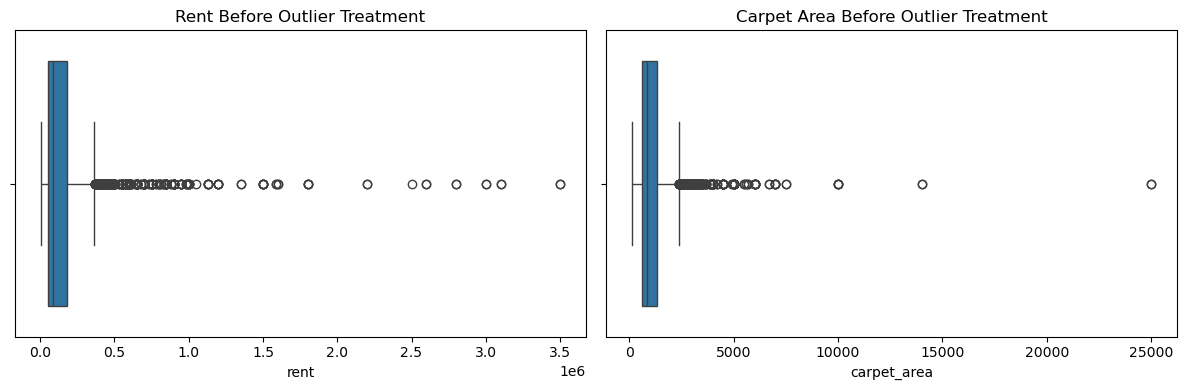

In [207]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["rent"])
plt.title("Rent Before Outlier Treatment")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["carpet_area"])
plt.title("Carpet Area Before Outlier Treatment")

plt.tight_layout()
plt.show()

### drop rowless targets , trim outliers

In [208]:
# Drop rows with no rent or no area
before = len(df)
df = df[df['rent'].notna() & df['carpet_area'].notna()].copy()
print(f'Dropped {before-len(df)} rows missing rent/area. {len(df)} remain.')

# IQR outlier trim on rent & area
def iqr_keep(s, k=3):
    q1,q3 = s.quantile(.25), s.quantile(.75); iqr=q3-q1
    return s.between(q1-k*iqr, q3+k*iqr)
mask = iqr_keep(df['rent']) & iqr_keep(df['carpet_area'])
df = df[mask].copy()
print(f'After IQR trim: {len(df)} rows')

Dropped 646 rows missing rent/area. 5224 remain.
After IQR trim: 5015 rows


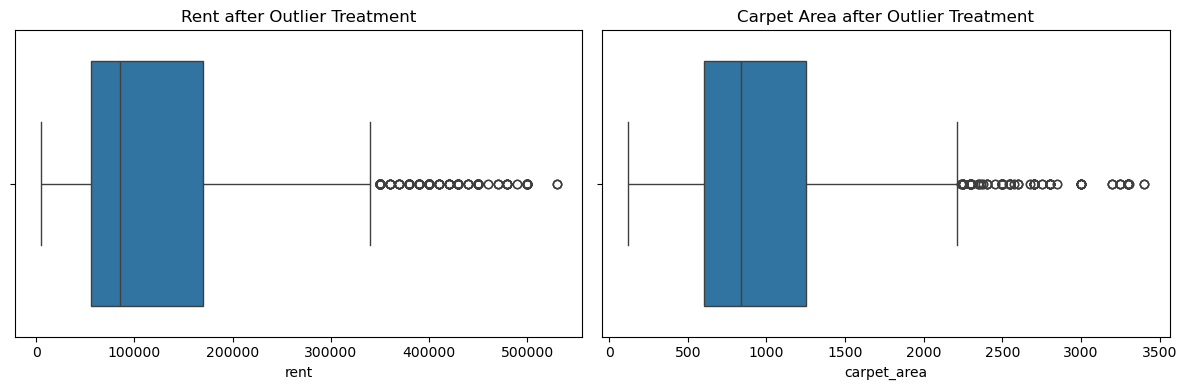

In [209]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["rent"])
plt.title("Rent after Outlier Treatment")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["carpet_area"])
plt.title("Carpet Area after Outlier Treatment")

plt.tight_layout()
plt.show()

**Strategy (decided from the null-% overview in section 0):**

Low-null categorical (furnishing 0.2%) → already mode-filled.
Categorical with meaningful missingness (facing) → already 'Unknown'.
Continuous features with 8–15% nulls (carpet_area, floor_num, total_floors, floor_ratio) → KNN imputation, because these correlate with bhk/locality/area and KNN borrows from similar listings — far better than a blanket median.
metro_mins missingness means 'not reported' → represented by has_metro, then filled with a 'far' sentinel so the model reads absence correctly.

In [210]:
print((df.isnull().mean()*100).round(2).sort_values(ascending=False).head(12))

metro_mins               82.61
nearby_raw               47.94
total_floors              7.36
floor_num                 7.36
floor_ratio               7.36
bhk                       0.00
rent                      0.00
locality                  0.00
carpet_area               0.00
available_immediately     0.00
furnishing_ord            0.00
facing_North              0.00
dtype: float64


In [212]:
knn_cols = ['carpet_area','floor_num','total_floors','floor_ratio','bhk']
# bhk included as a NEIGHBOUR signal (it's ~complete) to inform the others.
imputer = KNNImputer(n_neighbors=5)
df[knn_cols] = imputer.fit_transform(df[knn_cols])

# metro_mins: absence = 'not reported'. Fill with a large value; has_metro flags it.
FAR = df['metro_mins'].max()  # farthest reported
df['metro_mins'] = df['metro_mins'].fillna(FAR if pd.notna(FAR) else 60)

print('Remaining nulls after imputation:')
print(df.isnull().sum()[df.isnull().sum()>0])
print('(empty above = fully imputed)')

Remaining nulls after imputation:
nearby_raw    2404
dtype: int64
(empty above = fully imputed)


In [216]:
df.drop(columns=['nearby_raw'], inplace=True,errors = 'ignore')

In [218]:
df.isnull().sum()

property_type            0
locality                 0
rent                     0
bhk                      0
carpet_area              0
floor_num                0
total_floors             0
floor_ratio              0
available_immediately    0
furnishing_ord           0
facing_North             0
facing_North - East      0
facing_North - West      0
facing_South             0
facing_South - East      0
facing_South -West       0
facing_Unknown           0
facing_West              0
overlooks_garden         0
overlooks_pool           0
overlooks_main_road      0
metro_mins               0
has_metro                0
near_school              0
near_hospital            0
near_mall                0
near_bus                 0
near_railway             0
dtype: int64

### Saving the file

In [222]:
df.to_csv('../data/rentals_model_ready.csv', index=False)
print(f'Saved rentals_model_ready.csv  ->  {df.shape[0]} rows x {df.shape[1]} cols')
print('\nFinal feature columns:')
print([c for c in df.columns if c not in ['rent','log_rent']])

Saved rentals_model_ready.csv  ->  5015 rows x 28 cols

Final feature columns:
['property_type', 'locality', 'bhk', 'carpet_area', 'floor_num', 'total_floors', 'floor_ratio', 'available_immediately', 'furnishing_ord', 'facing_North', 'facing_North - East', 'facing_North - West', 'facing_South', 'facing_South - East', 'facing_South -West', 'facing_Unknown', 'facing_West', 'overlooks_garden', 'overlooks_pool', 'overlooks_main_road', 'metro_mins', 'has_metro', 'near_school', 'near_hospital', 'near_mall', 'near_bus', 'near_railway']
